<a href="https://colab.research.google.com/github/nimtruly/mlp-ka2/blob/main/ka2_16_0_6567_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KA2

In [ ]:
# Import pandas for working with tables and CSV files.
import pandas as pd  # Import the library needed for the next steps.
# Import NumPy for simple numerical operations.
import numpy as np  # Import the library needed for the next steps.


In [ ]:
# Load the training data.
train_df = pd.read_csv("/content/train.csv")  # Read the CSV file into a pandas DataFrame.
# Load the test data.
test_df = pd.read_csv("/content/test.csv")  # Read the CSV file into a pandas DataFrame.


In [ ]:
# Print the number of rows and columns in the training data.
print("Train shape:", train_df.shape)  # Display this information so we can check the result.
# Print the number of rows and columns in the test data.
print("Test shape:", test_df.shape)  # Display this information so we can check the result.


Train shape: (90000, 14)
Test shape: (30000, 13)


In [ ]:
# Show the first five rows of the training data.
train_df.head()  # Show the first few rows for a quick check.


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0


In [ ]:
# Show the first five rows of the test data.
test_df.head()  # Show the first few rows for a quick check.


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary
0,0,15765283,T'ien,645.0,France,Male,30.0,10,0.00,2.0,0.0,0.0,85901.09
1,1,15660157,Macleod,641.0,France,Male,37.0,10,146573.68,3.0,1.0,0.0,168023.72
2,2,15621267,Ejimofor,637.0,France,Female,32.0,6,0.00,1.0,0.0,0.0,148769.08
3,3,15651280,Nnaife,714.0,France,Male,37.0,7,0.00,2.0,1.0,0.0,172576.22
4,4,15764294,Ifeatu,716.0,Germany,Male,31.0,4,98899.91,1.0,1.0,1.0,47832.82


# 1. Identify data types of different columns
The data types of the different columns are identified and explicitly stated in the notebook

In [ ]:
# Show the column names, data types, and number of non-missing values.
train_df.info()  # Show column names, data types, and non-missing counts.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                90000 non-null  int64  
 1   customer_id       90000 non-null  int64  
 2   last_name         90000 non-null  object 
 3   credit_score      80444 non-null  float64
 4   country           83979 non-null  object 
 5   gender            90000 non-null  object 
 6   age               90000 non-null  float64
 7   tenure            90000 non-null  int64  
 8   acc_balance       82743 non-null  float64
 9   prod_count        85137 non-null  float64
 10  has_card          90000 non-null  float64
 11  is_active         90000 non-null  float64
 12  estimated_salary  90000 non-null  float64
 13  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(4), object(3)
memory usage: 9.6+ MB


# 2. Present descriptive statistics of numerical columns
Details such as min value, max value, mean and median for each numerical column is presented

In [ ]:
# Calculate basic statistics for numerical columns.
stats = train_df.describe().T  # Calculate basic descriptive statistics.
# Show only the minimum, maximum, mean, and median values.
print(stats[["min", "max", "mean", "50%"]])  # Display this information so we can check the result.
# The 50% value is the median.

                          min          max          mean          50%
id                       0.00     89999.00  4.499950e+04     44999.50
customer_id       15565701.00  15815690.00  1.569209e+07  15690164.00
credit_score           350.00       850.00  6.564971e+02       659.00
age                     18.00        92.00  3.811953e+01        37.00
tenure                   0.00        10.00  5.017022e+00         5.00
acc_balance              0.00    250898.09  5.545673e+04         0.00
prod_count               1.00         4.00  1.552932e+00         2.00
has_card                 0.00         1.00  7.542889e-01         1.00
is_active                0.00         1.00  4.971778e-01         0.00
estimated_salary        11.58    199992.48  1.123947e+05    117505.07
exit_status              0.00         1.00  2.116000e-01         0.00


# 3. Identify and handle the missing values
Missing values are identified and are dropped or imputed

In [ ]:
# Count missing values in every column.
train_df.isnull().sum()  # Check for missing values.


,0
id,0
customer_id,0
last_name,0
credit_score,9556
country,6021
gender,0
age,0
tenure,0
acc_balance,7257
prod_count,4863


In [ ]:
# Fill missing numerical values with their column median.
train_df.fillna(train_df.median(numeric_only=True), inplace=True)  # Replace missing values so the model can use the data.
# The median is less affected by extreme values than the mean.

In [ ]:
# Check the remaining missing values after filling numerical columns.
train_df.isnull().sum()  # Check for missing values.


,0
id,0
customer_id,0
last_name,0
credit_score,0
country,6021
gender,0
age,0
tenure,0
acc_balance,0
prod_count,0


In [ ]:
# Fill any remaining missing values, mainly categorical values, with the most common value.
train_df.fillna(train_df.mode().iloc[0], inplace=True)  # Replace missing values so the model can use the data.
# The mode is the most common value in a column.

In [ ]:
# Confirm that no missing values are left.
train_df.isnull().sum()  # Check for missing values.


,0
id,0
customer_id,0
last_name,0
credit_score,0
country,0
gender,0
age,0
tenure,0
acc_balance,0
prod_count,0


# 4. Identify and handle duplicates
Duplicates are identified and are dropped if they exist

In [ ]:
# Count how many complete duplicate rows are present.
duplicate_count = train_df.duplicated().sum()  # Check for duplicate rows.
# Print the number of duplicate rows.
print("Duplicate rows:", duplicate_count)  # Display this information so we can check the result.


Duplicate rows: 0


In [ ]:
# Explain the result from the duplicate check.
print("No duplicates found")  # Display this information so we can check the result.


No duplicates found


# 5. Identify and handle outliers
Outliers are identified and explanation for retaining / dropping is provided

In [ ]:
# Check numerical columns for possible outliers using the IQR method.
for col in train_df.select_dtypes(include=np.number).columns:  # Repeat this step for each item in the loop.
    # Find the first quartile.
    Q1 = train_df[col].quantile(0.25)  # Calculate a percentile used for the outlier check.
    # Find the third quartile.
    Q3 = train_df[col].quantile(0.75)  # Calculate a percentile used for the outlier check.
    # Calculate the interquartile range.
    IQR = Q3 - Q1  # Set or update `IQR` with the value calculated on this line.
    # Count values below the lower limit or above the upper limit.
    outliers = ((train_df[col] < Q1 - 1.5 * IQR) | (train_df[col] > Q3 + 1.5 * IQR)).sum()  # Calculate the total number or sum.
    # Print the number of possible outliers for this column.
    print(col, ":", outliers)  # Display this information so we can check the result.


id : 0
customer_id : 0
credit_score : 605
age : 3411
tenure : 0
acc_balance : 0
prod_count : 263
has_card : 22114
is_active : 0
estimated_salary : 0
exit_status : 19044


Outliers were identified using the IQR method. The identified outliers were retained because they may represent valid customer information and could contain useful information for classification.

#6. Present at least three visualizations and provide insights for the same
At least three visualizations on the data is presented

In [ ]:
# Import Matplotlib for plotting.
import matplotlib.pyplot as plt  # Import the library needed for the next steps.


Visualization 1: Exit status distribution

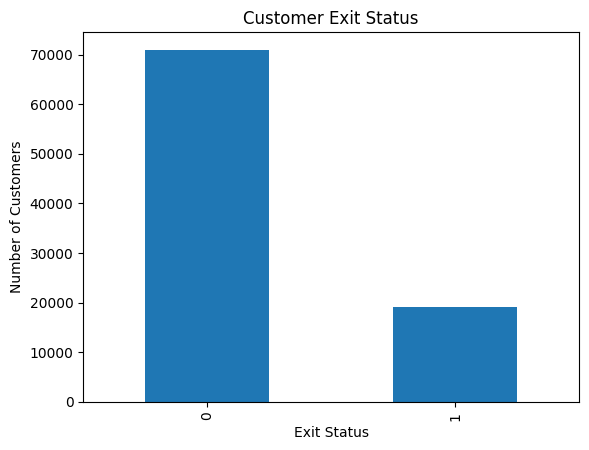

In [ ]:
# Count how many customers stayed and how many exited.
train_df["exit_status"].value_counts().plot(kind="bar")  # Create a simple chart from the data.
# Label the x-axis.
plt.xlabel("Exit Status")  # Label the horizontal axis.
# Label the y-axis.
plt.ylabel("Number of Customers")  # Label the vertical axis.
# Add a title.
plt.title("Customer Exit Status")  # Add a title to the chart.
# Display the chart.
plt.show()  # Show the chart.


Visualization 2: Age distribution

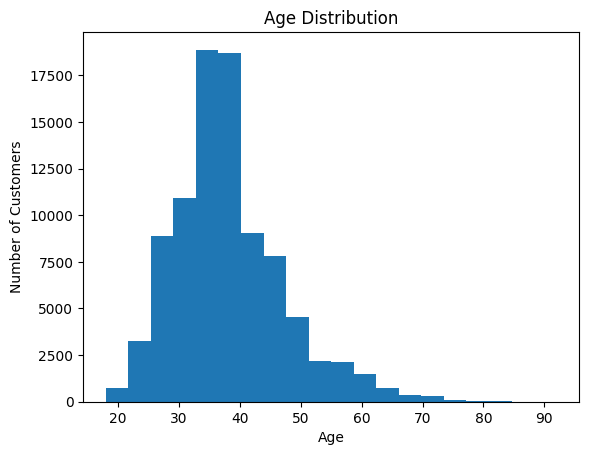

In [ ]:
# Plot the distribution of customer ages.
train_df["age"].plot(kind="hist", bins=20)  # Create a simple chart from the data.
# Label the x-axis.
plt.xlabel("Age")  # Label the horizontal axis.
# Label the y-axis.
plt.ylabel("Number of Customers")  # Label the vertical axis.
# Add a title.
plt.title("Age Distribution")  # Add a title to the chart.
# Display the chart.
plt.show()  # Show the chart.


Visualization 3: Target Distribution

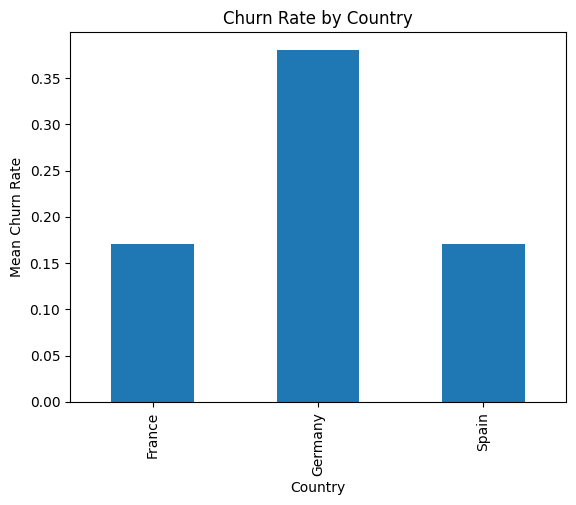

In [ ]:
# Calculate the average exit rate for each country.
country_churn = train_df.groupby("country")["exit_status"].mean()  # Group rows so we can calculate a value for each group.
# Plot the average exit rate for each country.
country_churn.plot(kind="bar")  # Create a simple chart from the data.
# Add a title.
plt.title("Churn Rate by Country")  # Add a title to the chart.
# Label the x-axis.
plt.xlabel("Country")  # Label the horizontal axis.
# Label the y-axis.
plt.ylabel("Mean Churn Rate")  # Label the vertical axis.
# Display the chart.
plt.show()  # Show the chart.


Visualization 4: Churn Rate by Country

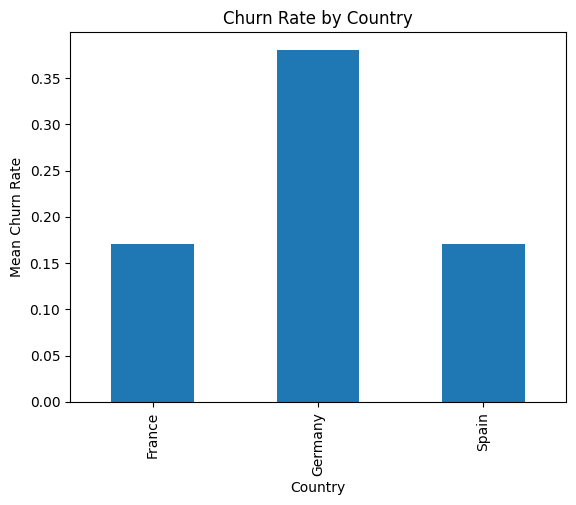

In [ ]:
# Calculate the average exit rate for each country.
country_churn = train_df.groupby("country")["exit_status"].mean()  # Group rows so we can calculate a value for each group.
# Plot the average exit rate for each country.
country_churn.plot(kind="bar")  # Create a simple chart from the data.
# Add a title.
plt.title("Churn Rate by Country")  # Add a title to the chart.
# Label the x-axis.
plt.xlabel("Country")  # Label the horizontal axis.
# Label the y-axis.
plt.ylabel("Mean Churn Rate")  # Label the vertical axis.
# Display the chart.
plt.show()  # Show the chart.


Visualization 5: Churn Rate by Gender

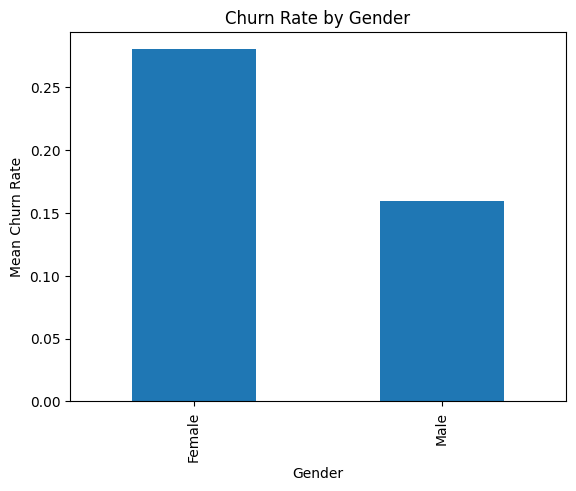

In [ ]:
# Calculate the average exit rate for each gender.
gender_churn = train_df.groupby("gender")["exit_status"].mean()  # Group rows so we can calculate a value for each group.
# Plot the average exit rate for each gender.
gender_churn.plot(kind="bar")  # Create a simple chart from the data.
# Add a title.
plt.title("Churn Rate by Gender")  # Add a title to the chart.
# Label the x-axis.
plt.xlabel("Gender")  # Label the horizontal axis.
# Label the y-axis.
plt.ylabel("Mean Churn Rate")  # Label the vertical axis.
# Display the chart.
plt.show()  # Show the chart.


Visualization 6: Account balance by exit status

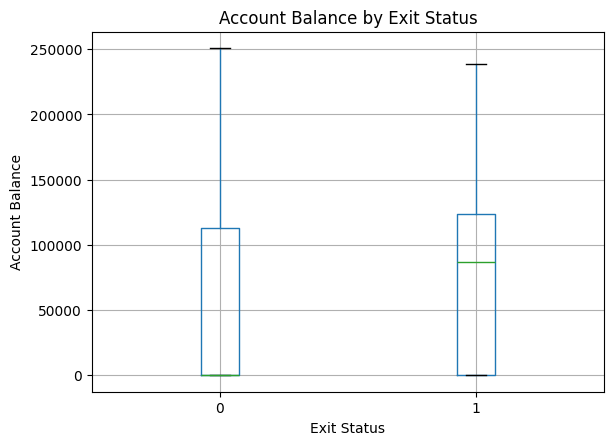

In [ ]:
# Compare account balances for customers who stayed and customers who exited.
train_df.boxplot(column="acc_balance", by="exit_status")  # Create a boxplot to compare the distributions.
# Label the x-axis.
plt.xlabel("Exit Status")  # Label the horizontal axis.
# Label the y-axis.
plt.ylabel("Account Balance")  # Label the vertical axis.
# Add a title.
plt.title("Account Balance by Exit Status")  # Add a title to the chart.
# Remove the automatic extra title created by pandas.
plt.suptitle("")  # Run this line as part of the data-processing or modelling step.
# Display the chart.
plt.show()  # Show the chart.


### What happens after visualization?
After understanding the data visually, we prepare it for machine learning. We remove ID columns, convert text categories into numbers, scale numerical values, split the data, encode the `last_name` column, and then train the models.


# 7. Scale Numerical Features and Encode Categorical Features
# Numerical features are scaled so models can work with similar feature ranges.
# Country and gender are converted into numerical 0/1 columns.
# ID columns are removed because they are identifiers, not useful measurements.
# last_name is kept temporarily because it is converted to a target-encoded feature later.

In [ ]:
# Show a quick view of the cleaned training data before preparing it for modeling.
train_df.head(2)  # Show the first few rows for a quick check.


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0


In [ ]:
# Create X with all input features except the target.
X = train_df.drop("exit_status", axis=1)  # Remove columns that should not be used in this step.
# Create y with the target we want to predict.
y = train_df["exit_status"]  # Set or update `y` with the value calculated on this line.


In [ ]:
# Remove the ID columns because they are only identifiers.
X = X.drop(["id", "customer_id"], axis=1)  # Remove columns that should not be used in this step.
# Remove the same ID columns from the test data.
test_features = test_df.drop(["id", "customer_id"], axis=1)  # Remove columns that should not be used in this step.


In [ ]:
# Convert the country and gender categories into 0/1 columns.
X = pd.get_dummies(X, columns=["country", "gender"])  # Convert categorical text values into numerical 0/1 columns.
# Apply the same one-hot encoding to the test data.
test_features = pd.get_dummies(test_features, columns=["country", "gender"])  # Convert categorical text values into numerical 0/1 columns.
# Make sure the test data has exactly the same columns as the training data.
test_features = test_features.reindex(columns=X.columns, fill_value=0)  # Make the columns match the required structure.


In [ ]:
# Import StandardScaler to put numerical features on a similar scale.
from sklearn.preprocessing import StandardScaler  # Import the specific tool needed for the next step.
# List the numerical columns that need scaling.
num_cols = ["credit_score", "age", "tenure", "acc_balance", "prod_count", "estimated_salary"]  # Set or update `num_cols` with the value calculated on this line.
# Create the scaler.
scaler = StandardScaler()  # Set or update `scaler` with the value calculated on this line.
# Learn the scaling values from the training data and transform it.
X[num_cols] = scaler.fit_transform(X[num_cols])  # Learn the transformation from this data and apply it.
# Use the same scaling values on the test data.
test_features[num_cols] = scaler.transform(test_features[num_cols])  # Apply the transformation learned earlier.


In [ ]:
# Check the data types after encoding and scaling.
print(X.dtypes)  # Display this information so we can check the result.


last_name            object
credit_score        float64
age                 float64
tenure              float64
acc_balance         float64
prod_count          float64
has_card            float64
is_active           float64
estimated_salary    float64
country_France         bool
country_Germany        bool
country_Spain          bool
gender_Female          bool
gender_Male            bool
dtype: object


The numerical features were scaled using StandardScaler so they have a similar range. Country and gender were converted into numerical columns using one-hot encoding. The last_name column was kept temporarily because it is converted into a numerical target-encoded feature later. The id and customer_id columns were removed because they are identifiers.

### Beginner note
From this point onward, the notebook trains several models, compares them using F1 score, tunes three models, finds a better prediction threshold, and finally creates the submission file. The comments in every code cell explain the purpose of each line.


# 8. Model Building (at least 7)
# Seven different classification models are trained and compared using F1 score.

In [ ]:
# Show a few prepared feature rows.
X.head(2)  # Show the first few rows for a quick check.


,last_name,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,Iredale,-1.292251,-1.142785,-1.432197,1.595092,-1.063766,1.0,1.0,-0.889040,True,False,False,False,True
1,Hs?,0.492209,-0.126427,0.706995,1.023477,0.779566,0.0,0.0,1.397994,True,False,False,True,False


In [ ]:
# Show a few target values.
y.head()  # Show the first few rows for a quick check.


,exit_status
0,0
1,0
2,0
3,0
4,0


In [ ]:
# Import the function used to split data into training and validation sets.
from sklearn.model_selection import train_test_split  # Import the specific tool needed for the next step.
# Split the data while keeping the same class proportion in both sets.
X_train, X_test, y_train, y_test = train_test_split(  # Split the data into training and validation parts.
    X,  # Run this line as part of the data-processing or modelling step.
    y,  # Run this line as part of the data-processing or modelling step.
    test_size=0.2,  # Set or update `test_size` with the value calculated on this line.
    random_state=42,  # Use a fixed random seed so the result is reproducible.
    stratify=y  # Set or update `stratify` with the value calculated on this line.
)  # Run this line as part of the data-processing or modelling step.


In [ ]:
# Print the size of the complete feature and target data.
print("Full data:", X.shape, y.shape)  # Display this information so we can check the result.
# Print the size of the training data.
print("Training data:", X_train.shape, y_train.shape)  # Display this information so we can check the result.
# Print the size of the validation data.
print("Validation data:", X_test.shape, y_test.shape)  # Display this information so we can check the result.


Full data: (90000, 14) (90000,)
Training data: (72000, 14) (72000,)
Validation data: (18000, 14) (18000,)


In [ ]:
# Import KFold so target encoding can be created without using validation targets.
from sklearn.model_selection import KFold  # Import the specific tool needed for the next step.
# Reset the row numbers after splitting the data.
X_train = X_train.reset_index(drop=True)  # Set or update `X_train` with the value calculated on this line.
X_test = X_test.reset_index(drop=True)  # Set or update `X_test` with the value calculated on this line.
y_train = y_train.reset_index(drop=True)  # Set or update `y_train` with the value calculated on this line.
y_test = y_test.reset_index(drop=True)  # Set or update `y_test` with the value calculated on this line.
# Create an empty column for the target-encoded last names.
X_train["last_name_te"] = 0.0  # Set or update `X_train["last_name_te"]` with the value calculated on this line.
# Create five folds for out-of-fold target encoding.
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # Use a fixed random seed so the result is reproducible.
# Process each fold separately.
for train_index, valid_index in kf.split(X_train):  # Repeat this step for each item in the loop.
    # Keep last names and target values from the fold used for calculating the encoding.
    temp = pd.DataFrame({  # Create a pandas DataFrame for storing the results.
        "last_name": X_train.loc[train_index, "last_name"],  # Run this line as part of the data-processing or modelling step.
        "target": y_train.loc[train_index]  # Run this line as part of the data-processing or modelling step.
    })  # Run this line as part of the data-processing or modelling step.
    # Calculate the average target and count for each last name.
    stats = temp.groupby("last_name")["target"].agg(["mean", "count"])  # Group rows so we can calculate a value for each group.
    # Smooth the group average so rare names do not get extreme values.
    mean = (stats["count"] * stats["mean"] + 20 * y_train.loc[train_index].mean()) / (stats["count"] + 20)  # Calculate the average value.
    # Put the calculated encoding into the validation part of this fold.
    X_train.loc[valid_index, "last_name_te"] = (  # Set or update `X_train.loc[valid_index, "last_name_te"]` with the value calculated on this line.
        X_train.loc[valid_index, "last_name"]  # Run this line as part of the data-processing or modelling step.
        .map(mean)  # Convert each value using the mapping created earlier.
        .fillna(y_train.loc[train_index].mean())  # Replace missing values so the model can use the data.
    )  # Run this line as part of the data-processing or modelling step.


In [ ]:
# Calculate target encoding values using only the training data.
stats = pd.DataFrame({  # Create a pandas DataFrame for storing the results.
    "last_name": X_train["last_name"],  # Run this line as part of the data-processing or modelling step.
    "target": y_train  # Run this line as part of the data-processing or modelling step.
}).groupby("last_name")["target"].agg(["mean", "count"])  # Group rows so we can calculate a value for each group.
# Smooth the group averages to make rare names safer to use.
mean = (stats["count"] * stats["mean"] + 20 * y_train.mean()) / (stats["count"] + 20)  # Calculate the average value.
# Apply the encoding to the validation data.
X_test["last_name_te"] = (  # Set or update `X_test["last_name_te"]` with the value calculated on this line.
    X_test["last_name"]  # Run this line as part of the data-processing or modelling step.
    .map(mean)  # Convert each value using the mapping created earlier.
    .fillna(y_train.mean())  # Replace missing values so the model can use the data.
)  # Run this line as part of the data-processing or modelling step.


In [ ]:
# Remove the original text column after creating its numerical encoding.
X_train = X_train.drop("last_name", axis=1)  # Remove columns that should not be used in this step.
# Remove the same text column from the validation data.
X_test = X_test.drop("last_name", axis=1)  # Remove columns that should not be used in this step.


In [ ]:
# Show the prepared training features.
X_train.head(2)  # Show the first few rows for a quick check.


,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,country_France,country_Germany,country_Spain,gender_Female,gender_Male,last_name_te
0,0.703701,-1.255713,-0.006069,-0.821438,0.779566,1.0,0.0,0.658532,True,False,False,False,True,0.158327
1,1.285303,-0.126427,1.063527,0.932883,0.779566,1.0,1.0,-0.370489,False,True,False,False,True,0.174689


In [ ]:
# Show the training target values.
y_train.head(2)  # Show the first few rows for a quick check.


,exit_status
0,0
1,0


In [ ]:
# Show the prepared validation features.
X_test.head(2)  # Show the first few rows for a quick check.


,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,country_France,country_Germany,country_Spain,gender_Female,gender_Male,last_name_te
0,1.298521,-0.126427,1.063527,-0.821438,-1.063766,1.0,0.0,0.723349,True,False,False,False,True,0.249453
1,0.029572,-0.239356,0.350463,0.991389,0.779566,0.0,0.0,-0.039185,True,False,False,True,False,0.134950


In [ ]:
# Import Logistic Regression.
from sklearn.linear_model import LogisticRegression  # Import the specific tool needed for the next step.
# Import F1 score for model evaluation.
from sklearn.metrics import f1_score  # Import the specific tool needed for the next step.
# Create the Logistic Regression model.
model1 = LogisticRegression(max_iter=1000)  # Set or update `model1` with the value calculated on this line.
# Train the model.
model1.fit(X_train, y_train)  # Train the machine-learning model using the training data.
# Predict the validation labels.
pred1 = model1.predict(X_test)  # Use the trained model to make predictions.
# Print the F1 score.
print("Logistic Regression F1:", f1_score(y_test, pred1))  # Display this information so we can check the result.


Logistic Regression F1: 0.4881253158160687


In [ ]:
# Import K-Nearest Neighbors.
from sklearn.neighbors import KNeighborsClassifier  # Import the specific tool needed for the next step.
# Create the KNN model using 15 neighbors.
model2 = KNeighborsClassifier(n_neighbors=15)  # Set or update `model2` with the value calculated on this line.
# Train the model.
model2.fit(X_train, y_train)  # Train the machine-learning model using the training data.
# Predict the validation labels.
pred2 = model2.predict(X_test)  # Use the trained model to make predictions.
# Print the F1 score.
print("KNN F1:", f1_score(y_test, pred2))  # Display this information so we can check the result.


KNN F1: 0.5786612828078894


In [ ]:
# Import the Decision Tree classifier.
from sklearn.tree import DecisionTreeClassifier  # Import the specific tool needed for the next step.
# Create a simple decision tree with a maximum depth of 8.
model3 = DecisionTreeClassifier(  # Set or update `model3` with the value calculated on this line.
    max_depth=8,  # Set or update `max_depth` with the value calculated on this line.
    random_state=42  # Use a fixed random seed so the result is reproducible.
)  # Run this line as part of the data-processing or modelling step.
# Train the model.
model3.fit(X_train, y_train)  # Train the machine-learning model using the training data.
# Predict the validation labels.
pred3 = model3.predict(X_test)  # Use the trained model to make predictions.
# Print the F1 score.
print("Decision Tree F1:", f1_score(y_test, pred3))  # Display this information so we can check the result.


Decision Tree F1: 0.6060152626066138


In [ ]:
# Import the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier  # Import the specific tool needed for the next step.
# Create a Random Forest with 200 trees.
model4 = RandomForestClassifier(  # Set or update `model4` with the value calculated on this line.
    n_estimators=200,  # Set or update `n_estimators` with the value calculated on this line.
    max_depth=10,  # Set or update `max_depth` with the value calculated on this line.
    random_state=42,  # Use a fixed random seed so the result is reproducible.
    n_jobs=-1  # Set or update `n_jobs` with the value calculated on this line.
)  # Run this line as part of the data-processing or modelling step.
# Train the model.
model4.fit(X_train, y_train)  # Train the machine-learning model using the training data.
# Predict the validation labels.
pred4 = model4.predict(X_test)  # Use the trained model to make predictions.
# Print the F1 score.
print("Random Forest F1:", f1_score(y_test, pred4))  # Display this information so we can check the result.


Random Forest F1: 0.5809399477806788


In [ ]:
# Import the Extra Trees classifier.
from sklearn.ensemble import ExtraTreesClassifier  # Import the specific tool needed for the next step.
# Create an Extra Trees model with 200 trees.
model5 = ExtraTreesClassifier(  # Set or update `model5` with the value calculated on this line.
    n_estimators=200,  # Set or update `n_estimators` with the value calculated on this line.
    max_depth=10,  # Set or update `max_depth` with the value calculated on this line.
    random_state=42,  # Use a fixed random seed so the result is reproducible.
    n_jobs=-1  # Set or update `n_jobs` with the value calculated on this line.
)  # Run this line as part of the data-processing or modelling step.
# Train the model.
model5.fit(X_train, y_train)  # Train the machine-learning model using the training data.
# Predict the validation labels.
pred5 = model5.predict(X_test)  # Use the trained model to make predictions.
# Print the F1 score.
print("Extra Trees F1:", f1_score(y_test, pred5))  # Display this information so we can check the result.


Extra Trees F1: 0.4843377908041766


In [ ]:
# Import Gradient Boosting.
from sklearn.ensemble import GradientBoostingClassifier  # Import the specific tool needed for the next step.
# Create the Gradient Boosting model.
model6 = GradientBoostingClassifier(  # Set or update `model6` with the value calculated on this line.
    n_estimators=100,  # Set or update `n_estimators` with the value calculated on this line.
    learning_rate=0.05,  # Set or update `learning_rate` with the value calculated on this line.
    max_depth=3,  # Set or update `max_depth` with the value calculated on this line.
    random_state=42  # Use a fixed random seed so the result is reproducible.
)  # Run this line as part of the data-processing or modelling step.
# Train the model.
model6.fit(X_train, y_train)  # Train the machine-learning model using the training data.
# Predict the validation labels.
pred6 = model6.predict(X_test)  # Use the trained model to make predictions.
# Print the F1 score.
print("Gradient Boosting F1:", f1_score(y_test, pred6))  # Display this information so we can check the result.


Gradient Boosting F1: 0.5895582329317269


In [ ]:
# Import HistGradientBoosting.
from sklearn.ensemble import HistGradientBoostingClassifier  # Import the specific tool needed for the next step.
# Create the HistGradientBoosting model.
model7 = HistGradientBoostingClassifier(  # Set or update `model7` with the value calculated on this line.
    max_iter=300,  # Set or update `max_iter` with the value calculated on this line.
    learning_rate=0.05,  # Set or update `learning_rate` with the value calculated on this line.
    max_leaf_nodes=31,  # Set or update `max_leaf_nodes` with the value calculated on this line.
    random_state=42  # Use a fixed random seed so the result is reproducible.
)  # Run this line as part of the data-processing or modelling step.
# Train the model.
model7.fit(X_train, y_train)  # Train the machine-learning model using the training data.
# Predict the validation labels.
pred7 = model7.predict(X_test)  # Use the trained model to make predictions.
# Print the F1 score.
print("HistGradientBoosting F1:", f1_score(y_test, pred7))  # Display this information so we can check the result.


HistGradientBoosting F1: 0.6160822249093107


# 9. Hyperparameter Tuning on Any 3 Models
# GridSearchCV tests a small number of parameter combinations and keeps the best one.

In [ ]:
# Import GridSearchCV for testing several parameter combinations.
from sklearn.model_selection import GridSearchCV  # Import the specific tool needed for the next step.


In [ ]:
# Set the Decision Tree values we want to test.
params1 = {  # Set or update `params1` with the value calculated on this line.
    "max_depth": [6, 8, 10]  # Run this line as part of the data-processing or modelling step.
}  # Run this line as part of the data-processing or modelling step.
# Create the Decision Tree grid search.
grid1 = GridSearchCV(  # Create a search that tests several parameter combinations.
    DecisionTreeClassifier(random_state=42),  # Use a fixed random seed so the result is reproducible.
    params1,  # Run this line as part of the data-processing or modelling step.
    cv=3,  # Set or update `cv` with the value calculated on this line.
    scoring="f1"  # Set or update `scoring` with the value calculated on this line.
)  # Run this line as part of the data-processing or modelling step.
# Train all parameter combinations.
grid1.fit(X_train, y_train)  # Train the machine-learning model using the training data.
# Show the best parameter combination.
print("Best Decision Tree parameters:", grid1.best_params_)  # Display this information so we can check the result.


Best Decision Tree parameters: {'max_depth': 10}


In [ ]:
# Set the Random Forest values we want to test.
params2 = {  # Set or update `params2` with the value calculated on this line.
    "n_estimators": [100, 200],  # Run this line as part of the data-processing or modelling step.
    "max_depth": [8, 10]  # Run this line as part of the data-processing or modelling step.
}  # Run this line as part of the data-processing or modelling step.
# Create the Random Forest grid search.
grid2 = GridSearchCV(  # Create a search that tests several parameter combinations.
    RandomForestClassifier(random_state=42),  # Use a fixed random seed so the result is reproducible.
    params2,  # Run this line as part of the data-processing or modelling step.
    cv=3,  # Set or update `cv` with the value calculated on this line.
    scoring="f1",  # Set or update `scoring` with the value calculated on this line.
    n_jobs=-1  # Set or update `n_jobs` with the value calculated on this line.
)  # Run this line as part of the data-processing or modelling step.
# Train all parameter combinations.
grid2.fit(X_train, y_train)  # Train the machine-learning model using the training data.
# Show the best parameter combination.
print("Best Random Forest parameters:", grid2.best_params_)  # Display this information so we can check the result.


Best Random Forest parameters: {'max_depth': 10, 'n_estimators': 200}


In [ ]:
# Set the HistGradientBoosting values we want to test.
params3 = {  # Set or update `params3` with the value calculated on this line.
    "learning_rate": [0.03, 0.05],  # Run this line as part of the data-processing or modelling step.
    "max_iter": [200, 300]  # Run this line as part of the data-processing or modelling step.
}  # Run this line as part of the data-processing or modelling step.
# Create the HistGradientBoosting grid search.
grid3 = GridSearchCV(  # Create a search that tests several parameter combinations.
    HistGradientBoostingClassifier(random_state=42),  # Use a fixed random seed so the result is reproducible.
    params3,  # Run this line as part of the data-processing or modelling step.
    cv=3,  # Set or update `cv` with the value calculated on this line.
    scoring="f1"  # Set or update `scoring` with the value calculated on this line.
)  # Run this line as part of the data-processing or modelling step.
# Train all parameter combinations.
grid3.fit(X_train, y_train)  # Train the machine-learning model using the training data.
# Show the best parameter combination.
print("Best HistGradientBoosting parameters:", grid3.best_params_)  # Display this information so we can check the result.


Best HistGradientBoosting parameters: {'learning_rate': 0.05, 'max_iter': 200}


In [ ]:
# Show the best Decision Tree settings and F1 score.
print("Decision Tree:", grid1.best_params_, grid1.best_score_)  # Display this information so we can check the result.
# Show the best Random Forest settings and F1 score.
print("Random Forest:", grid2.best_params_, grid2.best_score_)  # Display this information so we can check the result.
# Show the best HistGradientBoosting settings and F1 score.
print("HistGradientBoosting:", grid3.best_params_, grid3.best_score_)  # Display this information so we can check the result.


Decision Tree: {'max_depth': 10} 0.6049070776309701
Random Forest: {'max_depth': 10, 'n_estimators': 200} 0.5978351907795024
HistGradientBoosting: {'learning_rate': 0.05, 'max_iter': 200} 0.6287790077494839


# 10. Comparison of Model Performances
# The F1 scores of all seven models are collected and sorted from best to worst.

In [ ]:
# Store the F1 score of every model in one table.
results = pd.DataFrame({  # Create a pandas DataFrame for storing the results.
    "Model": [  # Run this line as part of the data-processing or modelling step.
        "Logistic Regression",  # Run this line as part of the data-processing or modelling step.
        "KNN",  # Run this line as part of the data-processing or modelling step.
        "Decision Tree",  # Run this line as part of the data-processing or modelling step.
        "Random Forest",  # Run this line as part of the data-processing or modelling step.
        "Extra Trees",  # Run this line as part of the data-processing or modelling step.
        "Gradient Boosting",  # Run this line as part of the data-processing or modelling step.
        "HistGradientBoosting"  # Run this line as part of the data-processing or modelling step.
    ],  # Run this line as part of the data-processing or modelling step.
    "F1 Score": [  # Run this line as part of the data-processing or modelling step.
        f1_score(y_test, pred1),  # Calculate the F1 score to measure classification performance.
        f1_score(y_test, pred2),  # Calculate the F1 score to measure classification performance.
        f1_score(y_test, pred3),  # Calculate the F1 score to measure classification performance.
        f1_score(y_test, pred4),  # Calculate the F1 score to measure classification performance.
        f1_score(y_test, pred5),  # Calculate the F1 score to measure classification performance.
        f1_score(y_test, pred6),  # Calculate the F1 score to measure classification performance.
        f1_score(y_test, pred7)  # Calculate the F1 score to measure classification performance.
    ]  # Run this line as part of the data-processing or modelling step.
})  # Run this line as part of the data-processing or modelling step.
# Sort the models from highest F1 score to lowest.
results = results.sort_values("F1 Score", ascending=False)  # Sort the results so they are easier to compare.
# Display the comparison table.
print(results)  # Display this information so we can check the result.


                  Model  F1 Score
6  HistGradientBoosting  0.616082
2         Decision Tree  0.606015
5     Gradient Boosting  0.589558
3         Random Forest  0.580940
1                   KNN  0.578661
0   Logistic Regression  0.488125
4           Extra Trees  0.484338


In [ ]:
# Show the training features before final model training.
X_train.head()  # Show the first few rows for a quick check.


,credit_score,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,country_France,country_Germany,country_Spain,gender_Female,gender_Male,last_name_te
0,0.703701,-1.255713,-0.006069,-0.821438,0.779566,1.0,0.0,0.658532,True,False,False,False,True,0.158327
1,1.285303,-0.126427,1.063527,0.932883,0.779566,1.0,1.0,-0.370489,False,True,False,False,True,0.174689
2,-1.384778,-0.578142,-1.075665,-0.821438,0.779566,0.0,0.0,-0.613850,True,False,False,True,False,0.210125
3,-0.062956,-0.465213,-1.075665,1.261036,0.779566,0.0,1.0,0.020534,False,True,False,True,False,0.229524
4,0.029572,0.664073,-1.075665,-0.821438,0.779566,1.0,1.0,-0.515889,True,False,False,False,True,0.187029


In [ ]:
# Get the probability that each validation customer will exit.
prob = model7.predict_proba(X_test)[:, 1]  # Calculate prediction probabilities instead of only 0/1 labels.
# Start with a normal classification threshold.
best_threshold = 0.5  # Set or update `best_threshold` with the value calculated on this line.
# Start the best F1 score at zero.
best_f1 = 0  # Set or update `best_f1` with the value calculated on this line.
# Test thresholds from 0.20 to 0.60.
for threshold in np.arange(0.20, 0.61, 0.01):  # Repeat this step for each item in the loop.
    # Convert probabilities into 0/1 predictions.
    pred = (prob >= threshold).astype(int)  # Convert the values into the required data type.
    # Calculate the F1 score at this threshold.
    score = f1_score(y_test, pred)  # Calculate the F1 score to measure classification performance.
    # Keep the threshold if it gives a better F1 score.
    if score > best_f1:  # Check this condition before running the indented code.
        # Save the new best F1 score.
        best_f1 = score  # Set or update `best_f1` with the value calculated on this line.
        # Save the threshold that produced it.
        best_threshold = threshold  # Set or update `best_threshold` with the value calculated on this line.
# Print the best threshold found.
print("Best threshold:", best_threshold)  # Display this information so we can check the result.
# Print the best validation F1 score.
print("Best F1:", best_f1)  # Display this information so we can check the result.


Best threshold: 0.35000000000000014
Best F1: 0.6439927026322648


In [ ]:
# Make a copy of all training features for the final model.
X_full = X.copy()  # Make a separate copy so the original data is not changed.
# Calculate the mean exit rate and number of rows for each last name.
stats = pd.DataFrame({  # Create a pandas DataFrame for storing the results.
    "last_name": X_full["last_name"],  # Run this line as part of the data-processing or modelling step.
    "target": y  # Run this line as part of the data-processing or modelling step.
}).groupby("last_name")["target"].agg(["mean", "count"])  # Group rows so we can calculate a value for each group.
# Smooth the target averages so rare names do not get extreme values.
mean = (stats["count"] * stats["mean"] + 20 * y.mean()) / (stats["count"] + 20)  # Calculate the average value.
# Convert last names into numerical target-encoded values.
X_full["last_name_te"] = (  # Set or update `X_full["last_name_te"]` with the value calculated on this line.
    X_full["last_name"]  # Run this line as part of the data-processing or modelling step.
    .map(mean)  # Convert each value using the mapping created earlier.
    .fillna(y.mean())  # Replace missing values so the model can use the data.
)  # Run this line as part of the data-processing or modelling step.


In [ ]:
# Apply the same target encoding to the real test data.
test_features["last_name_te"] = (  # Set or update `test_features["last_name_te"]` with the value calculated on this line.
    test_features["last_name"]  # Run this line as part of the data-processing or modelling step.
    .map(mean)  # Convert each value using the mapping created earlier.
    .fillna(y.mean())  # Replace missing values so the model can use the data.
)  # Run this line as part of the data-processing or modelling step.


In [ ]:
# Remove the original last_name text column from the final training data.
X_full = X_full.drop("last_name", axis=1)  # Remove columns that should not be used in this step.
# Remove the original last_name text column from the test data.
test_features = test_features.drop("last_name", axis=1)  # Remove columns that should not be used in this step.


In [ ]:
# Make sure the test data has exactly the same columns as the training data.
test_features = test_features.reindex(  # Make the columns match the required structure.
    columns=X_full.columns,  # Set or update `columns` with the value calculated on this line.
    fill_value=0  # Set or update `fill_value` with the value calculated on this line.
)  # Run this line as part of the data-processing or modelling step.


In [ ]:
# Create the final HistGradientBoosting model.
final_model = HistGradientBoostingClassifier(  # Set or update `final_model` with the value calculated on this line.
    max_iter=300,  # Set or update `max_iter` with the value calculated on this line.
    learning_rate=0.05,  # Set or update `learning_rate` with the value calculated on this line.
    max_leaf_nodes=31,  # Set or update `max_leaf_nodes` with the value calculated on this line.
    random_state=42  # Use a fixed random seed so the result is reproducible.
)  # Run this line as part of the data-processing or modelling step.
# Train the final model using all available training rows.
final_model.fit(X_full, y)  # Train the machine-learning model using the training data.


HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300,
                               random_state=42)

In [ ]:
# Predict the probability of exit for every test customer.
test_prob = final_model.predict_proba(test_features)[:, 1]  # Calculate prediction probabilities instead of only 0/1 labels.


In [ ]:
# Convert probabilities into 0/1 predictions using the best threshold.
test_pred = (test_prob >= best_threshold).astype(int)  # Convert the values into the required data type.
# Print how many customers are predicted to exit.
print("Predicted exits:", test_pred.sum())  # Display this information so we can check the result.
# Print the percentage of test customers predicted to exit.
print("Predicted exit rate:", test_pred.mean())  # Display this information so we can check the result.


Predicted exits: 6378
Predicted exit rate: 0.2126


In [ ]:
# Create the submission table with the required ID and prediction columns.
submission = pd.DataFrame({  # Create a pandas DataFrame for storing the results.
    "id": test_df["id"],  # Run this line as part of the data-processing or modelling step.
    "exit_status": test_pred  # Run this line as part of the data-processing or modelling step.
})  # Run this line as part of the data-processing or modelling step.
# Save the predictions as a CSV file.
submission.to_csv("submission25.csv", index=False)  # Set or update `submission.to_csv("submission16.csv", index` with the value calculated on this line.
# Show the first few submission rows.
print(submission.head())  # Display this information so we can check the result.


   id  exit_status
0   0            0
1   1            1
2   2            1
3   3            0
4   4            0
